In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection    import (train_test_split, StratifiedKFold,
                                         cross_val_score)
from sklearn.preprocessing      import RobustScaler, LabelEncoder
from sklearn.ensemble           import (RandomForestClassifier,
                                         ExtraTreesClassifier,
                                         GradientBoostingClassifier,
                                         BaggingClassifier,
                                         StackingClassifier)
from sklearn.tree               import DecisionTreeClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.decomposition      import PCA
from sklearn.metrics            import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
DATASET_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_application_data.csv"
LABEL_COLUMN = "Label"
BENIGN_LABEL = "Benign"

MODELS_DIR  = "models"
RESULTS_DIR = os.path.join("results", "layer3")
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEST_SIZE   = 0.20
VAL_SIZE    = 0.10
RANDOM_SEED = 42
CV_FOLDS    = 5

RF_N_ESTIMATORS      = 300
RF_MAX_DEPTH         = None
RF_MIN_SAMPLES_SPLIT = 5
RF_MIN_SAMPLES_LEAF  = 2

XGB_N_ESTIMATORS = 300
XGB_MAX_DEPTH    = 8
XGB_LR           = 0.05
XGB_SUBSAMPLE    = 0.8
XGB_COLSAMPLE    = 0.8

APPLICATION_FEATURES = [
    "Pkt Size Avg",
    "Pkt Len Mean",
    "Pkt Len Max",
    "Pkt Len Min",
    "Pkt Len Std",
    "Pkt Len Var",
    "Fwd Pkt Len Max",
    "Fwd Pkt Len Min",
    "Fwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Max",
    "Bwd Pkt Len Min",
    "Bwd Pkt Len Mean",
    "Bwd Pkt Len Std",
    "Fwd Seg Size Min",
    "Fwd Seg Size Avg",
    "Bwd Seg Size Avg",
    "TotLen Fwd Pkts",
    "Subflow Fwd Byts"
]

In [3]:
known_path = os.path.join(MODELS_DIR, "/home/fyp_ids_e20/Eniyavan/Layer_models/layer2/Step1/models/layer2_known_classes.txt")
if os.path.exists(known_path):
    with open(known_path) as fh:
        known_classes = set(line.strip() for line in fh if line.strip())
    print(f"Loaded {len(known_classes)} known classes <- {known_path}")
    for c in sorted(known_classes): print(f"  • {c}")
else:
    known_classes = None
    print("layer2_known_classes.txt not found — using ALL attack classes.")

df = pd.read_csv(DATASET_PATH, low_memory=False)
df.columns       = df.columns.str.strip()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()
print(f"\nTotal rows : {len(df):,}")

df = df[df[LABEL_COLUMN] != BENIGN_LABEL]
if known_classes:
    df = df[df[LABEL_COLUMN].isin(known_classes)]
df = df.reset_index(drop=True)
print(f"Known attack rows : {len(df):,}")

found   = [f for f in APPLICATION_FEATURES if f in df.columns]
missing = [f for f in APPLICATION_FEATURES if f not in df.columns]
print(f"\nFeatures found   : {len(found)} / {len(APPLICATION_FEATURES)}")
if missing: print(f"Features missing : {missing}")

counts = df[LABEL_COLUMN].value_counts()
print("\nClass distribution:")
for cls, cnt in counts.items():
    bar = chr(9608) * int(30 * cnt / counts.max())
    print(f"  {cls:<38}  {cnt:>8,}  {bar}")

X      = df[found].values.astype(np.float64)
labels = df[LABEL_COLUMN].reset_index(drop=True)

Loaded 13 known classes <- /home/fyp_ids_e20/Eniyavan/Layer_models/layer2/Step1/models/layer2_known_classes.txt
  • Bot
  • Brute Force -Web
  • Brute Force -XSS
  • DDOS attack-HOIC
  • DDOS attack-LOIC-UDP
  • DDoS attacks-LOIC-HTTP
  • DoS attacks-GoldenEye
  • DoS attacks-Hulk
  • DoS attacks-SlowHTTPTest
  • DoS attacks-Slowloris
  • FTP-BruteForce
  • Infilteration
  • SSH-Bruteforce

Total rows : 6,870,587
Known attack rows : 2,748,148

Features found   : 19 / 19

Class distribution:
  DDOS attack-HOIC                         686,012  ██████████████████████████████
  DDoS attacks-LOIC-HTTP                   576,191  █████████████████████████
  DoS attacks-Hulk                         461,912  ████████████████████
  Bot                                      286,191  ████████████
  FTP-BruteForce                           193,360  ████████
  SSH-Bruteforce                           187,589  ████████
  Infilteration                            161,934  ███████
  DoS attacks-SlowHTTPT

In [4]:
le = LabelEncoder()
y  = le.fit_transform(labels)
joblib.dump(le, os.path.join(MODELS_DIR, "layer3_label_encoder.pkl"))
print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")
print(f"Label encoder saved -> {MODELS_DIR}/layer3_label_encoder.pkl")

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, random_state=RANDOM_SEED, stratify=y_tv)

print(f"\nTrain      : {len(y_train):,}")
print(f"Validation : {len(y_val):,}")
print(f"Test       : {len(y_test):,}")

Classes (13): ['Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SSH-Bruteforce']
Label encoder saved -> models/layer3_label_encoder.pkl

Train      : 1,923,703
Validation : 274,815
Test       : 549,630


In [5]:
scaler_path = os.path.join(MODELS_DIR, "/home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl")
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print(f"Loaded Layer 1 scaler <- {scaler_path}")
else:
    scaler = RobustScaler()
    scaler.fit(X_train)
    joblib.dump(scaler, os.path.join(MODELS_DIR,"layer3_scaler.pkl"))
    print("New RobustScaler fitted and saved.")

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print(f"Scaled: Train{X_train_s.shape}  Val{X_val_s.shape}  Test{X_test_s.shape}")

Loaded Layer 1 scaler <- /home/fyp_ids_e20/Eniyavan/Layer_models/layer1/models/layer1_scaler.pkl
Scaled: Train(1923703, 19)  Val(274815, 19)  Test(549630, 19)


In [6]:
trained = {}

base_defs = [
    ("Random Forest", RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)),

    ("XGBoost", XGBClassifier(
        n_estimators=XGB_N_ESTIMATORS, max_depth=XGB_MAX_DEPTH,
        learning_rate=XGB_LR, subsample=XGB_SUBSAMPLE,
        colsample_bytree=XGB_COLSAMPLE, use_label_encoder=False,
        eval_metric="mlogloss", random_state=RANDOM_SEED,
        n_jobs=-1, early_stopping_rounds=20)),

    ("Extra Trees", ExtraTreesClassifier(
        n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
        min_samples_split=RF_MIN_SAMPLES_SPLIT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)),

    ("Gradient Boost", GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_SEED)),

    ("Bagging DT", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=10, class_weight="balanced", random_state=RANDOM_SEED),
        n_estimators=200, max_samples=0.8, max_features=0.8,
        bootstrap=True, random_state=RANDOM_SEED, n_jobs=-1)),
]

for name, clf in base_defs:
    t0 = time.time()
    if name == "XGBoost":
        clf.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
    else:
        clf.fit(X_train_s, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_s))
    val_f1  = f1_score(y_val, clf.predict(X_val_s), average="weighted", zero_division=0)
    print(f"  {name:<20}  {time.time()-t0:5.1f}s  "
          f"val_acc={val_acc*100:.2f}%  val_f1={val_f1:.4f}")
    joblib.dump(clf, os.path.join(MODELS_DIR,
                f"layer3_{name.lower().replace(' ','_')}.pkl"))
    trained[name] = clf

  Random Forest          22.4s  val_acc=74.30%  val_f1=0.7149
  XGBoost               958.6s  val_acc=74.37%  val_f1=0.7153
  Extra Trees            22.4s  val_acc=74.29%  val_f1=0.7148
  Gradient Boost        6144.2s  val_acc=74.34%  val_f1=0.7148
  Bagging DT             42.3s  val_acc=74.11%  val_f1=0.7123


In [9]:
from sklearn.preprocessing import StandardScaler as _SS
from sklearn.pipeline import Pipeline

xgb_fixed = XGBClassifier(
    n_estimators=trained["XGBoost"].best_iteration + 1,
    max_depth=XGB_MAX_DEPTH, learning_rate=XGB_LR,
    subsample=XGB_SUBSAMPLE, colsample_bytree=XGB_COLSAMPLE,
    use_label_encoder=False, eval_metric="mlogloss",
    random_state=RANDOM_SEED, n_jobs=-1,
)
xgb_fixed.fit(X_train_s, y_train)

estimators = [
    ("random_forest",  trained["Random Forest"]),
    ("xgboost",        xgb_fixed),
    ("extra_trees",    trained["Extra Trees"]),
    ("gradient_boost", trained["Gradient Boost"]),
    ("bagging_dt",     trained["Bagging DT"]),
]

meta_lr = Pipeline([
    ("scaler", _SS()),
    ("lr", LogisticRegression(
        max_iter=5000,
        C=1.0,
        class_weight="balanced",
        solver="saga",
        random_state=RANDOM_SEED,
        n_jobs=-1)),
])
stacker = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_lr,
    cv=5, stack_method="predict_proba",
    n_jobs=-1, passthrough=False,
)
t0 = time.time()
stacker.fit(X_train_s, y_train)
val_acc = accuracy_score(y_val, stacker.predict(X_val_s))
val_f1  = f1_score(y_val, stacker.predict(X_val_s), average="weighted", zero_division=0)
print(f"Stacking — {time.time()-t0:.1f}s  val_acc={val_acc*100:.2f}%  val_f1={val_f1:.4f}")
trained["Stacking"] = stacker
joblib.dump(stacker, os.path.join(MODELS_DIR, "layer3_stacking.pkl"))

[13:11:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:11:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:11:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:11:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:11:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Stacking — 30780.8s  val_acc=74.29%  val_f1=0.7148


['models/layer3_stacking.pkl']

In [10]:
results     = []
model_names = list(trained.keys())
class_names = list(le.classes_)
palette     = ["steelblue","darkorange","seagreen","mediumpurple","tomato","goldenrod"]
all_preds   = []

for name, clf in trained.items():
    preds = clf.predict(X_test_s)
    all_preds.append(preds)
    acc  = accuracy_score(y_test, preds)
    f1_w = f1_score(y_test, preds, average="weighted", zero_division=0)
    f1_m = f1_score(y_test, preds, average="macro",    zero_division=0)
    status = "TARGET MET" if acc >= 0.90 else "Below 90%"
    print(f"{'='*50}\n  {name}")
    print(f"  Accuracy    : {acc*100:.4f}%   [{status}]")
    print(f"  F1 Weighted : {f1_w:.4f}   F1 Macro : {f1_m:.4f}")
    print(classification_report(y_test, preds, target_names=class_names, digits=4))
    results.append({"Model":name, "Accuracy%":round(acc*100,4),
                    "F1 Weighted":round(f1_w,4), "F1 Macro":round(f1_m,4),
                    "90%+ Met":"Yes" if acc>=0.90 else "No"})

df_results = pd.DataFrame(results).sort_values("Accuracy%", ascending=False)
df_results.to_csv(os.path.join(RESULTS_DIR,"layer3_model_summary.csv"), index=False)
print("\n" + "-"*62)
print(df_results.to_string(index=False))

  Random Forest
  Accuracy    : 74.1590%   [Below 90%]
  F1 Weighted : 0.7132   F1 Macro : 0.6762
                          precision    recall  f1-score   support

                     Bot     1.0000    0.4978    0.6647     57238
        Brute Force -Web     0.1452    0.7377    0.2426       122
        Brute Force -XSS     1.0000    0.5870    0.7397        46
        DDOS attack-HOIC     0.6027    1.0000    0.7521    137203
    DDOS attack-LOIC-UDP     0.7489    0.9913    0.8532       346
  DDoS attacks-LOIC-HTTP     0.9999    0.5017    0.6682    115238
   DoS attacks-GoldenEye     0.9998    0.6690    0.8016      8302
        DoS attacks-Hulk     0.8087    1.0000    0.8942     92382
DoS attacks-SlowHTTPTest     0.0000    0.0000    0.0000     27978
   DoS attacks-Slowloris     0.9994    0.7875    0.8809      2198
          FTP-BruteForce     0.5710    1.0000    0.7269     38672
           Infilteration     0.9997    0.8260    0.9046     32387
          SSH-Bruteforce     1.0000    0.49

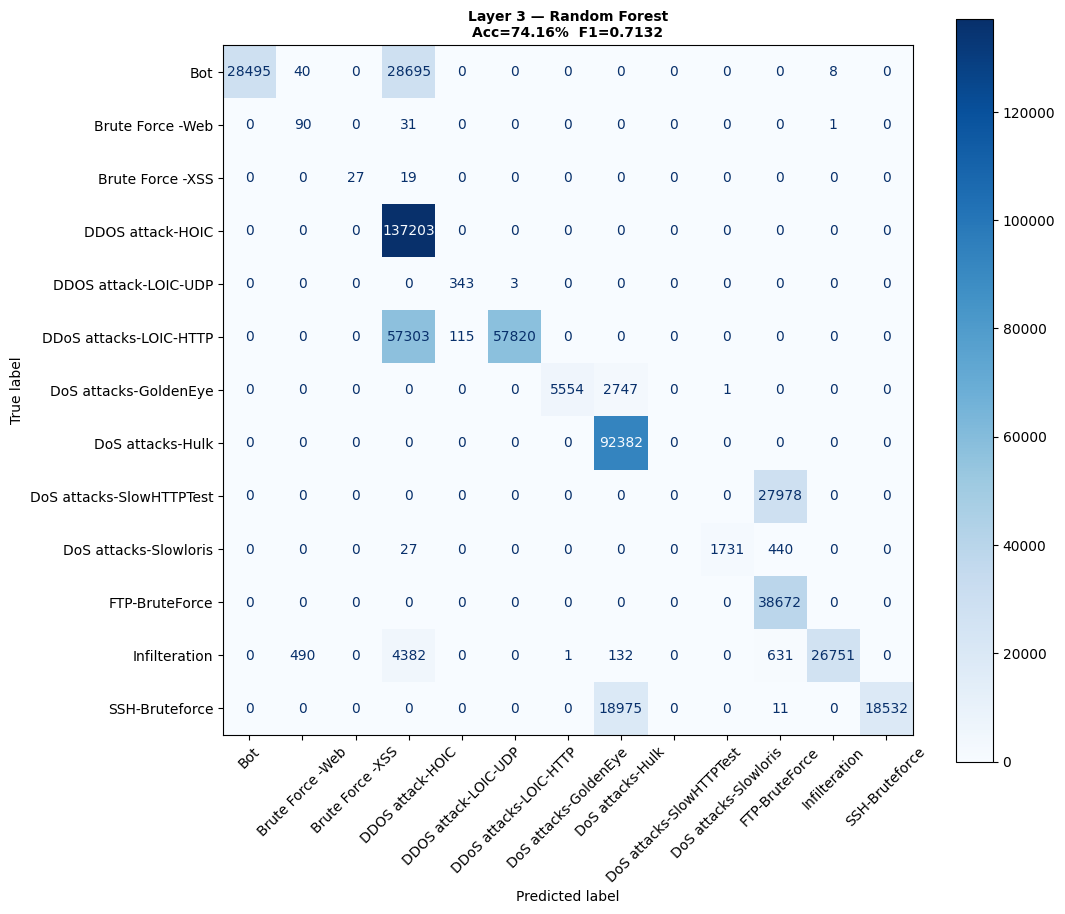

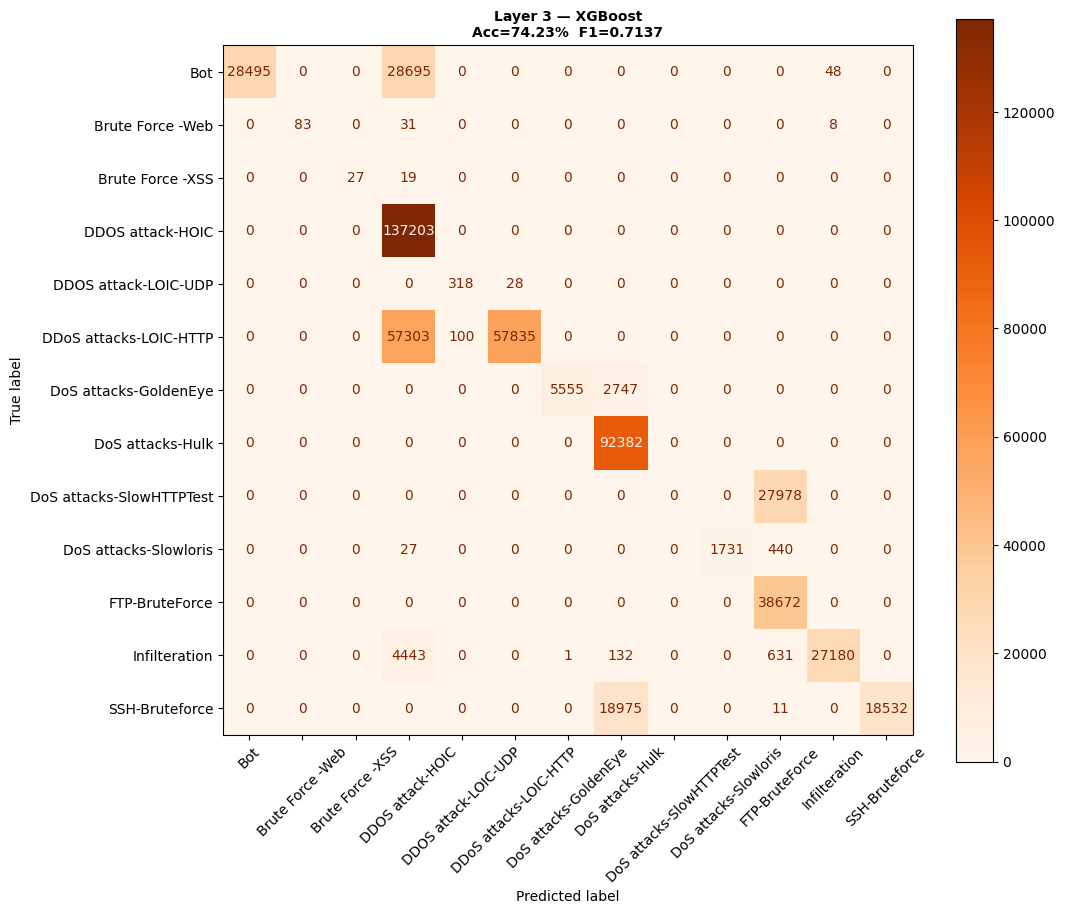

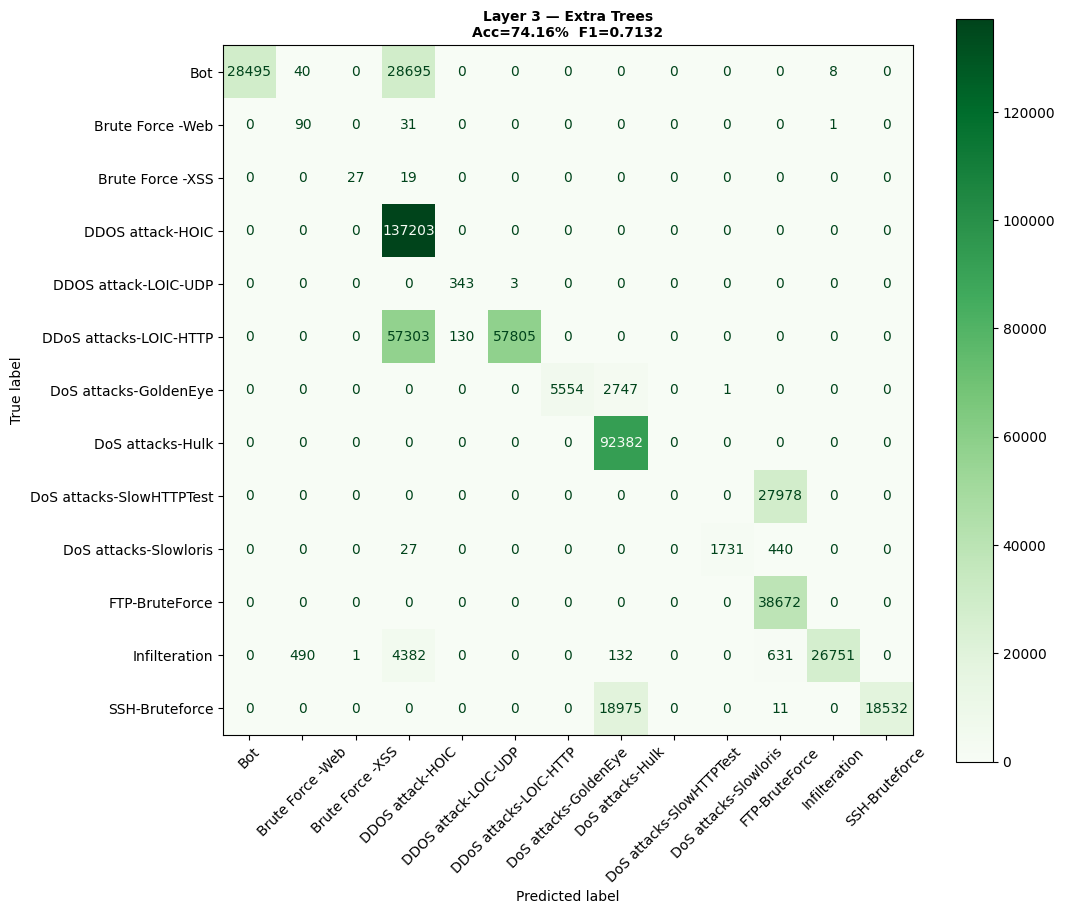

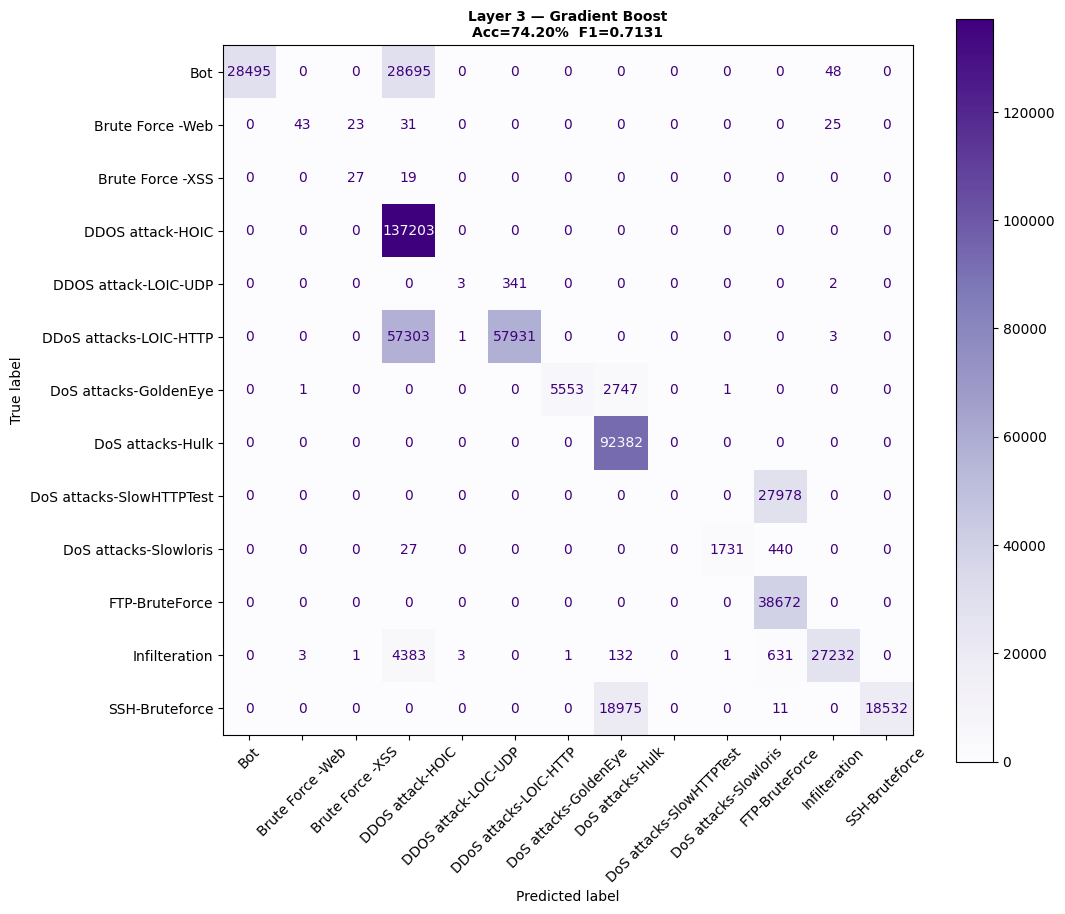

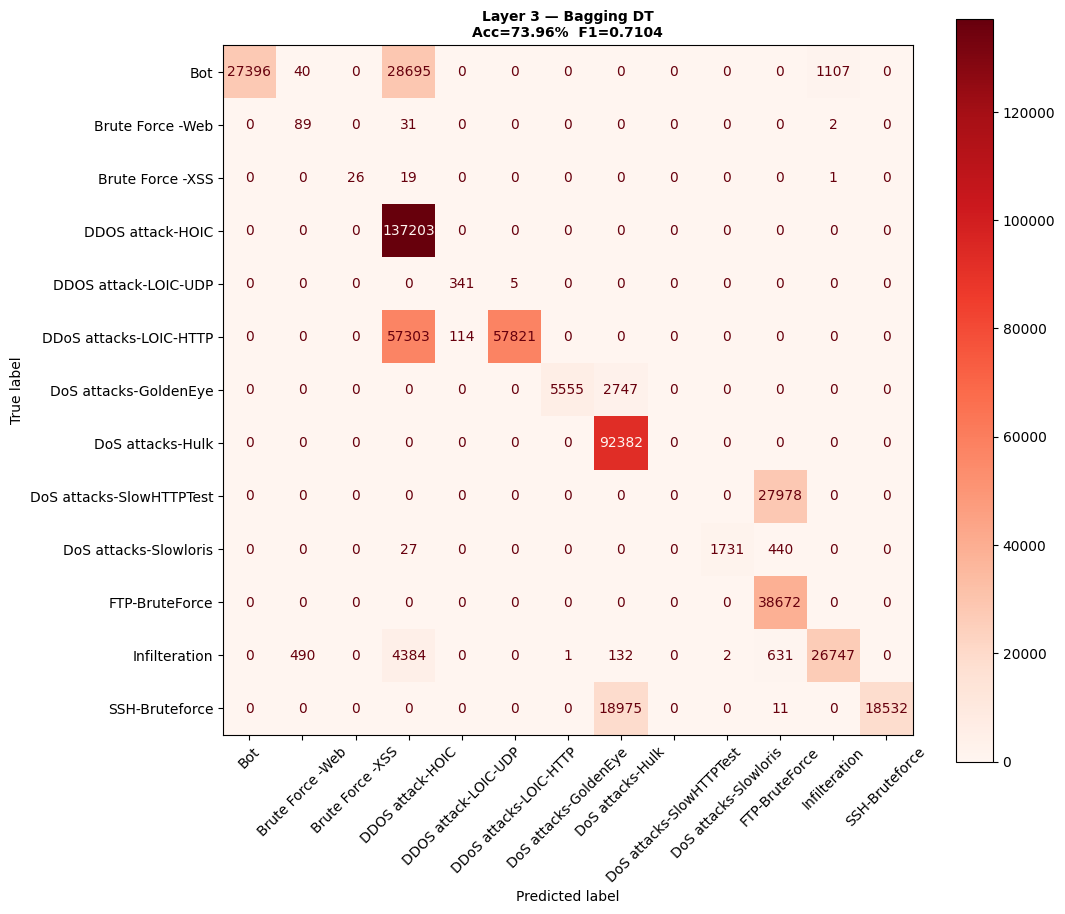

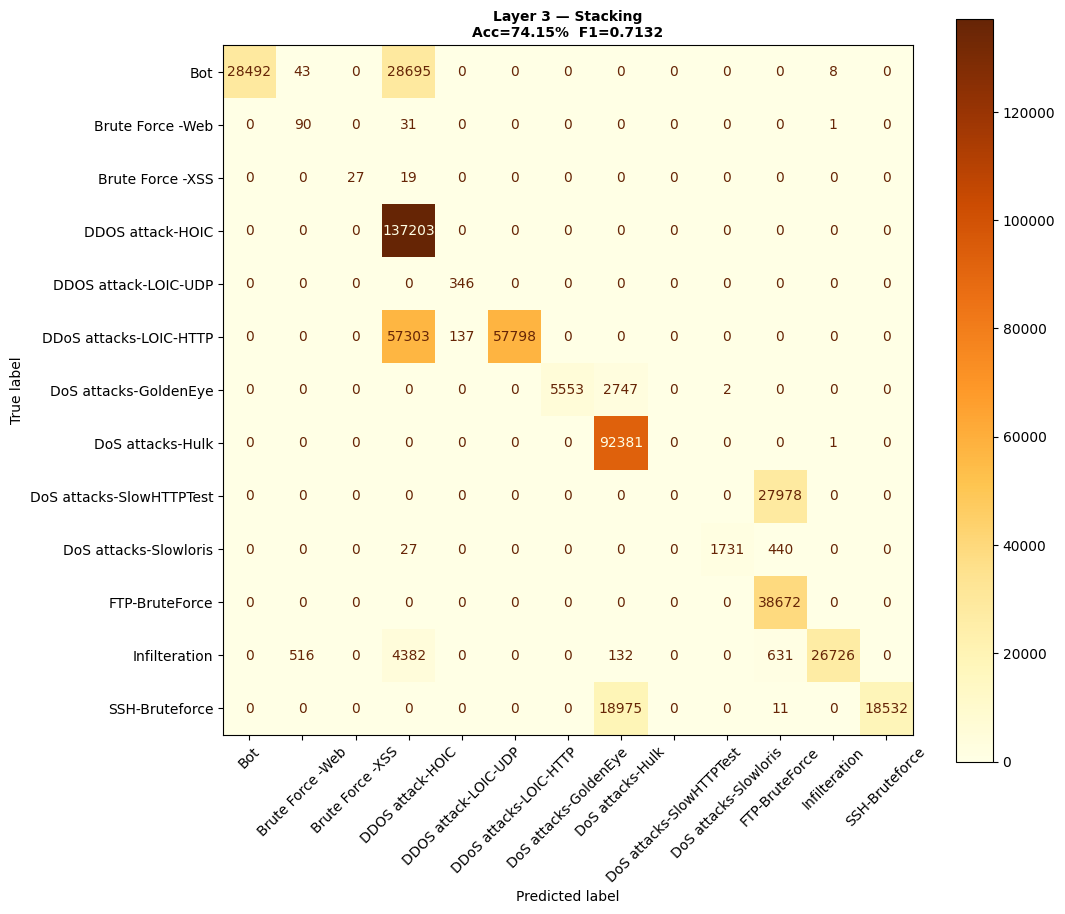

In [11]:
n_classes = len(class_names)
for i, (nm, preds) in enumerate(zip(model_names, all_preds)):
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="weighted", zero_division=0)
    sz  = max(8, n_classes * 0.85)
    fig, ax = plt.subplots(figsize=(sz, sz*0.85))
    cmaps_list = ["Blues","Oranges","Greens","Purples","Reds","YlOrBr"]
    ConfusionMatrixDisplay(confusion_matrix(y_test,preds),
                           display_labels=class_names).plot(
        ax=ax, colorbar=True, cmap=cmaps_list[i], xticks_rotation=45)
    ax.set_title(f"Layer 3 — {nm}\nAcc={acc*100:.2f}%  F1={f1:.4f}",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    safe = nm.lower().replace(" ","_")
    plt.savefig(os.path.join(RESULTS_DIR,f"layer3_cm_{safe}.png"),dpi=150,bbox_inches="tight")
    plt.show()

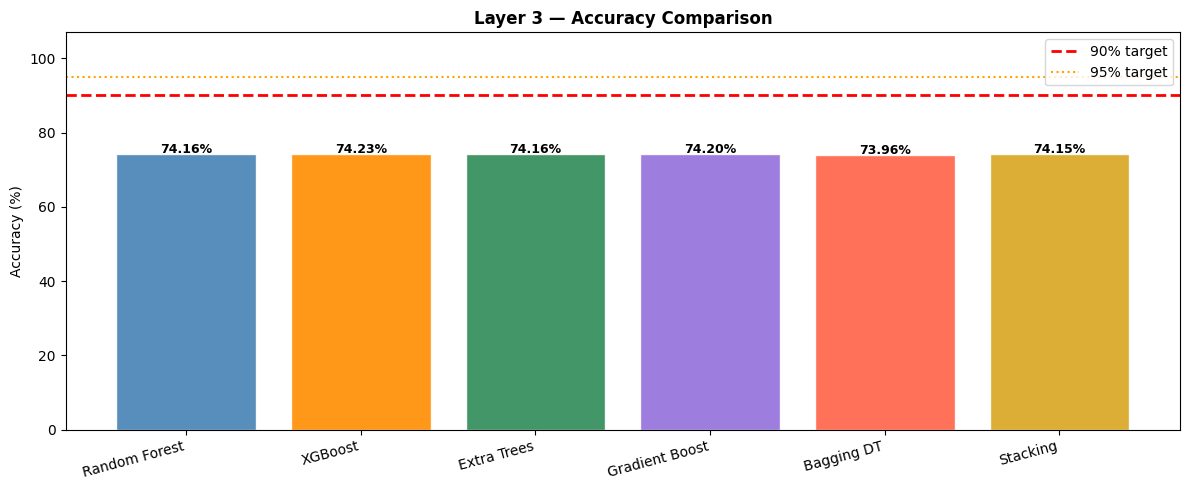

In [12]:
n_models = len(model_names)
accs = [accuracy_score(y_test,p)*100 for p in all_preds]
fig,ax = plt.subplots(figsize=(12,5))
bars = ax.bar(model_names,accs,color=palette[:n_models],edgecolor="white",alpha=0.9)
ax.axhline(90,color="red",linestyle="--",lw=2,label="90% target")
ax.axhline(95,color="orange",linestyle=":",lw=1.5,label="95% target")
for bar,v in zip(bars,accs):
    ax.text(bar.get_x()+bar.get_width()/2,v+0.3,
            f"{v:.2f}%",ha="center",fontsize=9,fontweight="bold")
ax.set_ylim(0,107); ax.set_ylabel("Accuracy (%)")
ax.set_title("Layer 3 — Accuracy Comparison",fontweight="bold")
ax.legend(); plt.xticks(rotation=15,ha="right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer3_accuracy_comparison.png"),dpi=150,bbox_inches="tight")
plt.show()

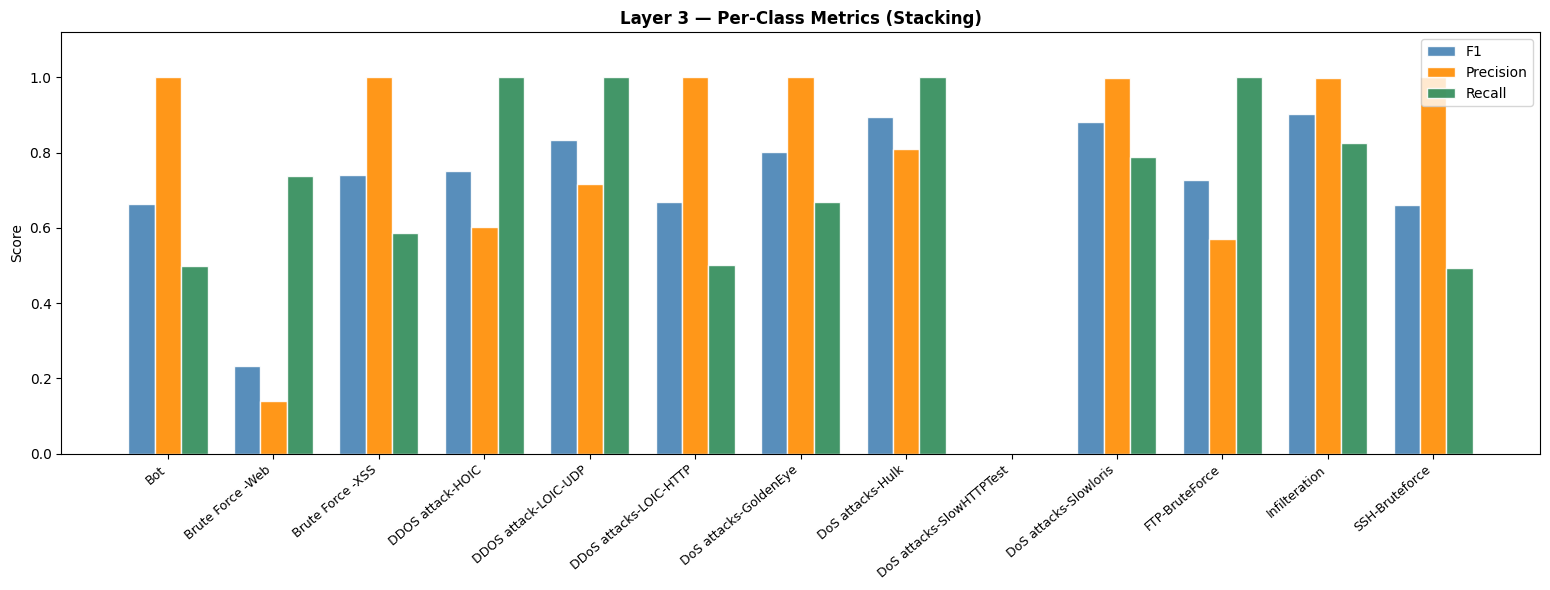

In [13]:
stk_preds    = all_preds[-1]
per_cls_f1   = f1_score(y_test,stk_preds,average=None,zero_division=0)
per_cls_prec = precision_score(y_test,stk_preds,average=None,zero_division=0)
per_cls_rec  = recall_score(y_test,stk_preds,average=None,zero_division=0)
x,w = np.arange(n_classes),0.25
fig,ax = plt.subplots(figsize=(max(12,n_classes*1.2),6))
for i_,(met,vals,col) in enumerate([("F1",per_cls_f1,"steelblue"),
                                      ("Precision",per_cls_prec,"darkorange"),
                                      ("Recall",per_cls_rec,"seagreen")]):
    ax.bar(x+i_*w,vals,w,label=met,color=col,edgecolor="white",alpha=0.9)
ax.set_xticks(x+w); ax.set_xticklabels(class_names,rotation=40,ha="right",fontsize=9)
ax.set_ylim(0,1.12); ax.set_ylabel("Score")
ax.set_title("Layer 3 — Per-Class Metrics (Stacking)",fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer3_per_class_metrics.png"),dpi=150,bbox_inches="tight")
plt.show()

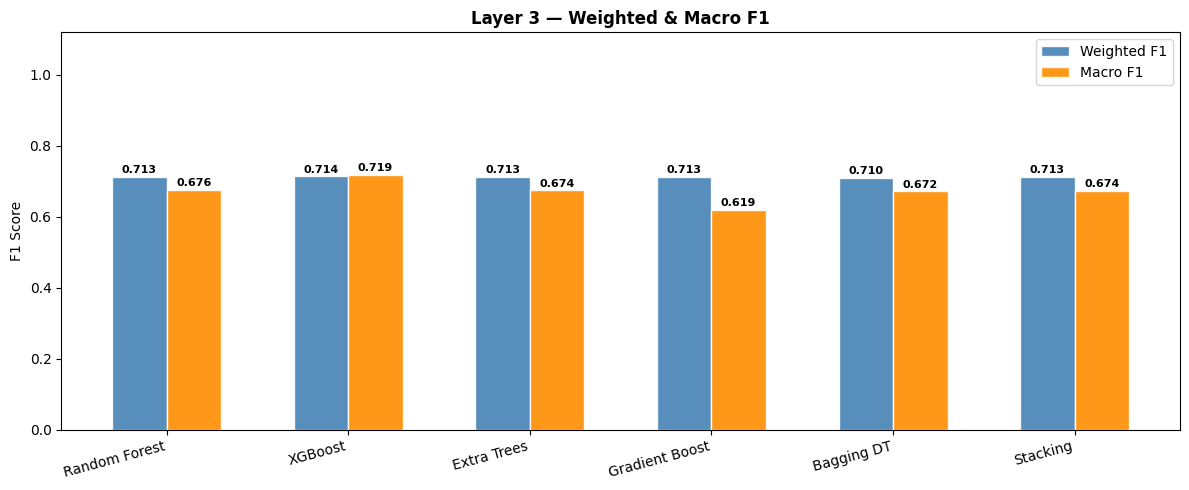

In [14]:
f1s_w=[f1_score(y_test,p,average="weighted",zero_division=0) for p in all_preds]
f1s_m=[f1_score(y_test,p,average="macro",   zero_division=0) for p in all_preds]
x4,w4=np.arange(n_models),0.3
fig,ax=plt.subplots(figsize=(12,5))
bs1=ax.bar(x4,    f1s_w,w4,label="Weighted F1",color="steelblue",edgecolor="white",alpha=0.9)
bs2=ax.bar(x4+w4, f1s_m,w4,label="Macro F1",  color="darkorange",edgecolor="white",alpha=0.9)
for bs,vals in [(bs1,f1s_w),(bs2,f1s_m)]:
    for b,v in zip(bs,vals):
        ax.text(b.get_x()+b.get_width()/2,v+0.005,f"{v:.3f}",
                ha="center",va="bottom",fontsize=8,fontweight="bold")
ax.set_xticks(x4+w4/2); ax.set_xticklabels(model_names,rotation=15,ha="right")
ax.set_ylim(0,1.12); ax.set_ylabel("F1 Score")
ax.set_title("Layer 3 — Weighted & Macro F1",fontweight="bold"); ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer3_f1_comparison.png"),dpi=150,bbox_inches="tight")
plt.show()

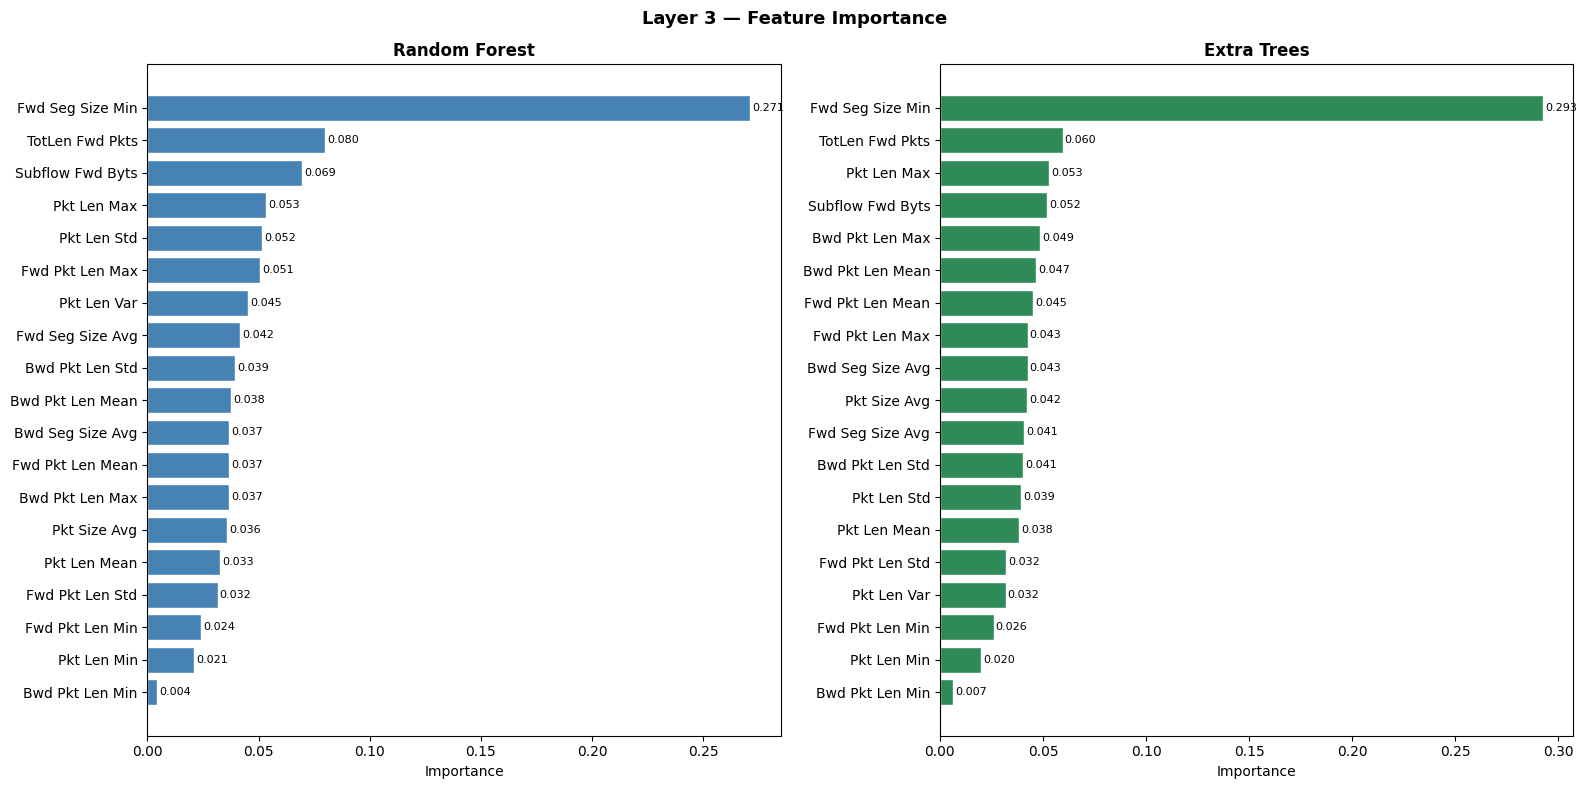

In [15]:
fig,axes=plt.subplots(1,2,figsize=(16,8))
for ax,(nm,col) in zip(axes,[("Random Forest","steelblue"),("Extra Trees","seagreen")]):
    if nm in trained:
        imp=trained[nm].feature_importances_; idx=np.argsort(imp)
        bs=ax.barh([found[i] for i in idx],imp[idx],color=col,edgecolor="white")
        for b,v in zip(bs,imp[idx]):
            ax.text(v+0.001,b.get_y()+b.get_height()/2,f"{v:.3f}",va="center",fontsize=8)
        ax.set_xlabel("Importance"); ax.set_title(f"{nm}",fontweight="bold")
plt.suptitle("Layer 3 — Feature Importance",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer3_feature_importance.png"),dpi=150,bbox_inches="tight")
plt.show()

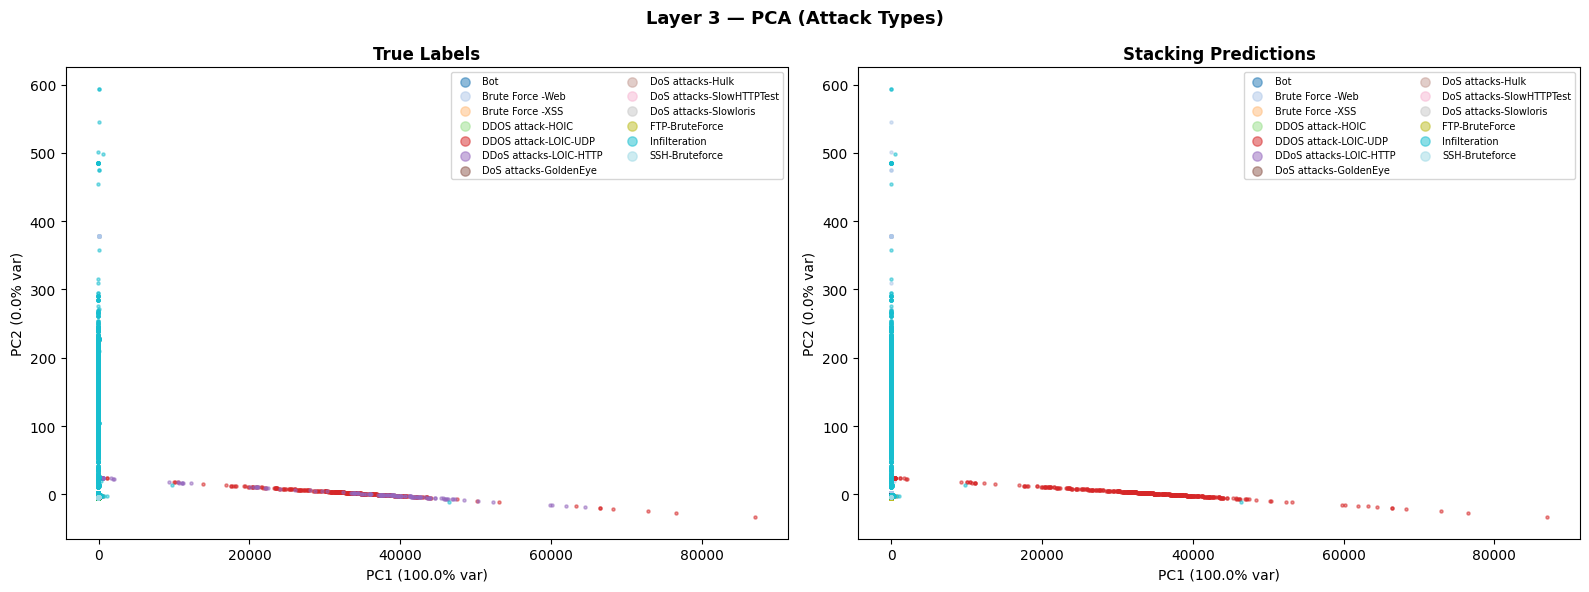

In [16]:
pca=PCA(n_components=2,random_state=RANDOM_SEED); X2d=pca.fit_transform(X_test_s)
var=pca.explained_variance_ratio_; stk_pred=all_preds[-1]
cmap_pca=plt.cm.get_cmap("tab20",n_classes)
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,(lbl,title) in zip(axes,[(y_test,"True Labels"),(stk_pred,"Stacking Predictions")]):
    for ci,cname in enumerate(class_names):
        mask=(lbl==ci)
        ax.scatter(X2d[mask,0],X2d[mask,1],c=[cmap_pca(ci)],s=5,alpha=0.5,label=cname)
    ax.set_xlabel(f"PC1 ({100*var[0]:.1f}% var)"); ax.set_ylabel(f"PC2 ({100*var[1]:.1f}% var)")
    ax.set_title(title,fontweight="bold"); ax.legend(markerscale=3,fontsize=7,loc="upper right",ncol=2)
plt.suptitle("Layer 3 — PCA (Attack Types)",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer3_pca_visualisation.png"),dpi=150,bbox_inches="tight")
plt.show()

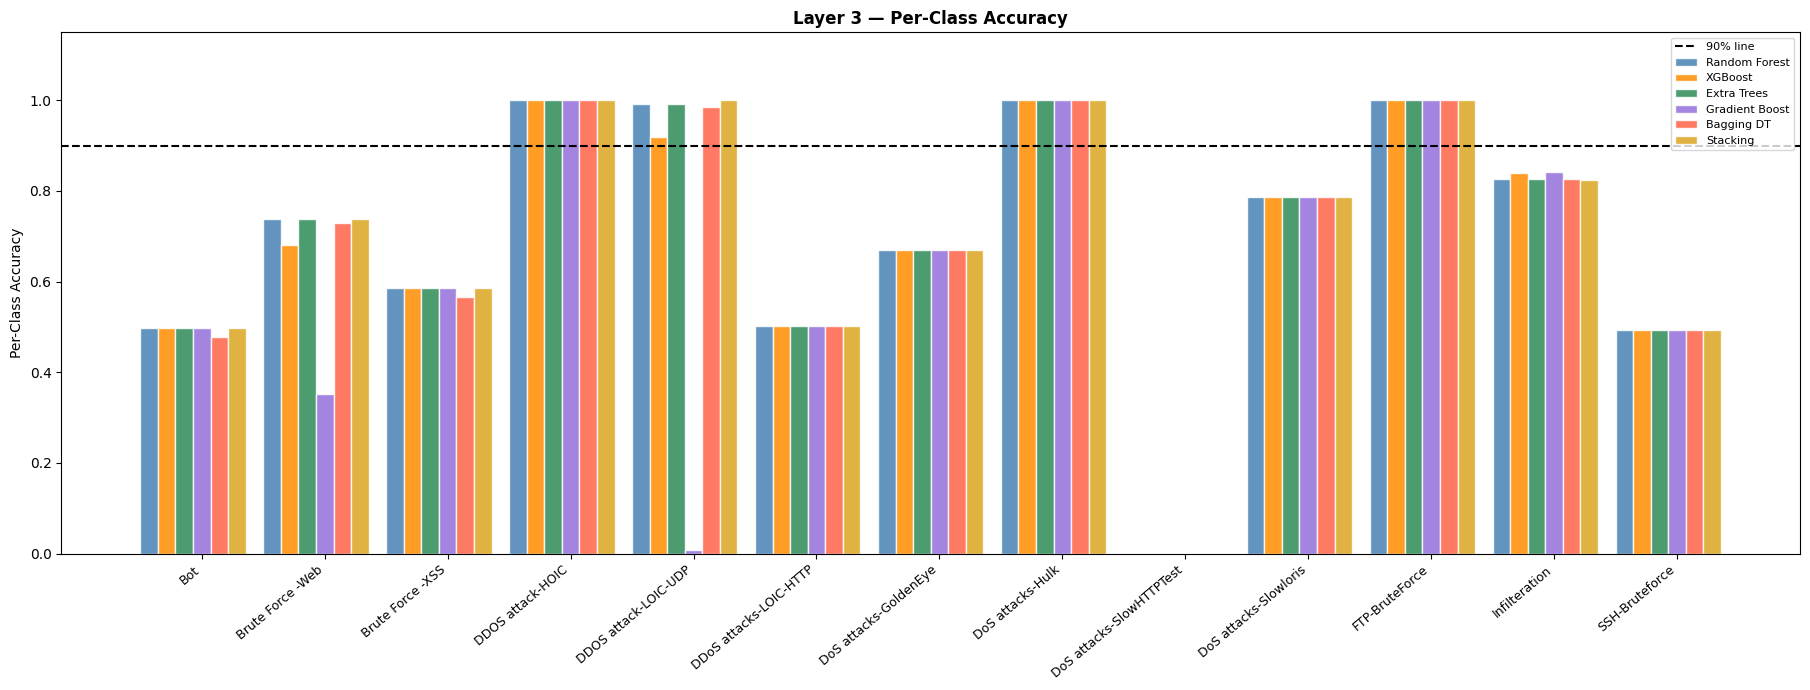

In [17]:
x8=np.arange(n_classes); w8=1.0/(n_models+1)
fig,ax=plt.subplots(figsize=(max(14,n_classes*1.4),7))
for i_,(nm,preds) in enumerate(zip(model_names,all_preds)):
    cls_acc=[float((preds[y_test==ci]==ci).mean()) if (y_test==ci).sum()>0 else 0
             for ci in range(n_classes)]
    ax.bar(x8+i_*w8,cls_acc,w8,label=nm,color=palette[i_],edgecolor="white",alpha=0.85)
ax.axhline(0.90,color="black",linestyle="--",lw=1.5,label="90% line")
ax.set_xticks(x8+w8*n_models/2); ax.set_xticklabels(class_names,rotation=40,ha="right",fontsize=9)
ax.set_ylim(0,1.15); ax.set_ylabel("Per-Class Accuracy")
ax.set_title("Layer 3 — Per-Class Accuracy",fontweight="bold"); ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"layer3_per_class_accuracy.png"),dpi=150,bbox_inches="tight")
plt.show()